# Part 1b: Tidal Stream Energy Production [25 pts]

In [1]:
import sys
from pathlib import Path
sys.path.append("../src")

import numpy as np
import matplotlib.pyplot as plt

from tidaltools import harmonics, stream_turbine

figures_dir = Path("../figures")
figures_dir.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "axes.grid": True, "grid.alpha": 0.3})

C_U, C_SP, C_REF = "#2a78d6", "#eb6834", "#8a8984"

## Tidal resource

Regenerated from the Part 1a constituents so this notebook runs on its own.

In [2]:
CONSTITUENTS = {
    "M2": (2.2185, 12.4206),
    "S2": (0.4335, 12.0),
    "K2": (0.4437, 11.965),
}
N_HOURS = 365 * 24
DT = 1.0            # h

t = np.arange(N_HOURS) * DT
U = harmonics.superpose_constituents(t, CONSTITUENTS)
speed = np.abs(U)

## Turbine data

In [3]:
U_CUT_IN = 1.0      # m/s
U_CUT_OUT = 3.0     # m/s
P_RATED = 1.0e6     # W
ETA = 0.45          # water-to-wire efficiency
A_CAPTURE = 165.0   # m2
RHO = 1025.0        # kg/m3

U_rated = stream_turbine.rated_speed(P_RATED, RHO, A_CAPTURE, ETA)
P = stream_turbine.bidirectional_power(U, RHO, A_CAPTURE, ETA, P_RATED, U_CUT_IN, U_CUT_OUT)

print(f"Rated speed U_r   : {U_rated:.3f} m/s")
print(f"Power at cut-in   : {stream_turbine.bidirectional_power(np.array([U_CUT_IN]), RHO, A_CAPTURE, ETA, P_RATED, U_CUT_IN, U_CUT_OUT)[0] / 1e3:.1f} kW")

Rated speed U_r   : 2.973 m/s
Power at cut-in   : 38.1 kW


Rated power is reached at 2.97 m/s, just below the 3.0 m/s cut-out, so there is almost no flat rated region.

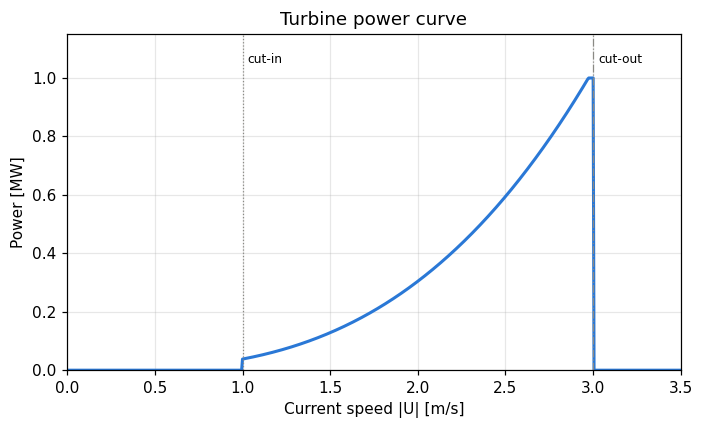

In [4]:
u_pc = np.linspace(0, 3.5, 701)
p_pc = stream_turbine.bidirectional_power(u_pc, RHO, A_CAPTURE, ETA, P_RATED, U_CUT_IN, U_CUT_OUT)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(u_pc, p_pc / 1e6, color=C_U, lw=2)
ax.axvline(U_CUT_IN, color=C_REF, lw=0.8, ls=":")
ax.axvline(U_CUT_OUT, color=C_REF, lw=0.8, ls="-.")
ax.text(U_CUT_IN + 0.03, 1.05, "cut-in", fontsize=8)
ax.text(U_CUT_OUT + 0.03, 1.05, "cut-out", fontsize=8)
ax.set_xlim(0, 3.5)
ax.set_ylim(0, 1.15)
ax.set_xlabel("Current speed |U| [m/s]")
ax.set_ylabel("Power [MW]")
ax.set_title("Turbine power curve")
fig.tight_layout()
fig.savefig(figures_dir / "part2_tidal_power_curve.png", dpi=300)
plt.show()

## Generated power over 31 days [15 pts]

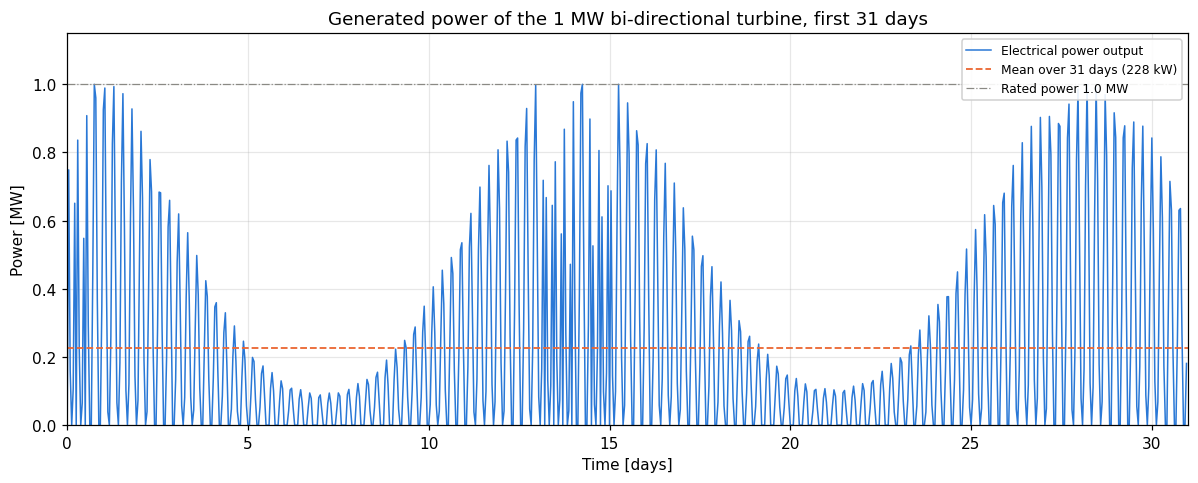

In [5]:
n31 = 31 * 24
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t[:n31] / 24, P[:n31] / 1e6, color=C_U, lw=1.0, label="Electrical power output")
ax.axhline(P[:n31].mean() / 1e6, color=C_SP, lw=1.2, ls="--",
           label=f"Mean over 31 days ({P[:n31].mean() / 1e3:.0f} kW)")
ax.axhline(P_RATED / 1e6, color=C_REF, lw=0.8, ls="-.", label="Rated power 1.0 MW")
ax.set_xlim(0, 31)
ax.set_ylim(0, 1.15)
ax.set_xlabel("Time [days]")
ax.set_ylabel("Power [MW]")
ax.set_title("Generated power of the 1 MW bi-directional turbine, first 31 days")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
fig.tight_layout()
fig.savefig(figures_dir / "part2_tidal_power_31days.png", dpi=300)
plt.show()

## Annual results [10 pts]

In [6]:
P_mean = P.mean()
P_max = P.max()
AEY = stream_turbine.annual_energy_yield(P, dt=DT)              # Wh
CF = stream_turbine.capacity_factor(AEY, P_RATED, hours_in_year=N_HOURS)

print(f"Annual mean power      : {P_mean / 1e3:.1f} kW")
print(f"Maximum power produced : {P_max / 1e3:.1f} kW")
print(f"AEY                    : {AEY / 1e6:.1f} MWh = {AEY / 1e9:.3f} GWh")
print(f"Capacity factor        : {CF:.3f} = {CF * 100:.1f} %")
print()
print(f"Hours generating       : {np.sum(P > 0)} h ({np.mean(P > 0) * 100:.1f} %)")
print(f"Hours below cut-in     : {np.sum(speed < U_CUT_IN)} h ({np.mean(speed < U_CUT_IN) * 100:.1f} %)")
print(f"Hours at rated power   : {np.sum(P >= P_RATED)} h")
print(f"Hours above cut-out    : {np.sum(speed > U_CUT_OUT)} h")

Annual mean power      : 199.4 kW
Maximum power produced : 1000.0 kW
AEY                    : 1746.3 MWh = 1.746 GWh
Capacity factor        : 0.199 = 19.9 %

Hours generating       : 6012 h (68.6 %)
Hours below cut-in     : 2701 h (30.8 %)
Hours at rated power   : 22 h
Hours above cut-out    : 47 h
